# Exploratory Data Analysis (EDA)
## Dataset: Hotel Bookings
---

## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

## 2. Load Dataset

In [2]:
try:
    df = pd.read_csv("../data/raw/hotel_bookings.csv")
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("File not found. Please check the file path.")

Dataset loaded successfully.


## 3. Jumlah Baris dan Kolom Dataset

In [4]:
jumlah_baris = df.shape[0]
jumlah_kolom = df.shape[1]
nama_kolom = [col for col in df.columns]
print(f"Jumlah baris: {jumlah_baris}")
print(f"Jumlah kolom: {jumlah_kolom}")
print(f"Nama kolom: {nama_kolom}")

Jumlah baris: 119390
Jumlah kolom: 32
Nama kolom: ['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date']


## 4. Lima Baris Data Teratas

In [5]:
print(df.head())

          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel            0        342               2015               July   
1  Resort Hotel            0        737               2015               July   
2  Resort Hotel            0          7               2015               July   
3  Resort Hotel            0         13               2015               July   
4  Resort Hotel            0         14               2015               July   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   
2                        27                          1   
3                        27                          1   
4                        27                          1   

   stays_in_weekend_nights  stays_in_week_nights  adults  ...  deposit_type  \
0                        0                     0       2  ...    No Deposit   
1     

## 5. Ringkasan Dataset

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

## 6. Ringkasan Statistik Data Numerik

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


## 7. Cek Apakah Ada Missing Value

In [8]:
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

## 8. Visualisasi Missing Value

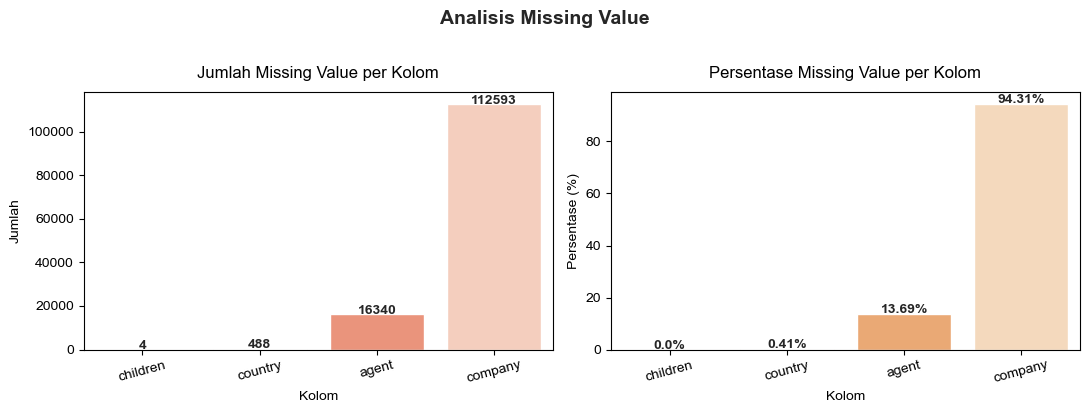

   Kolom  Jumlah Missing  Persentase (%)
children               4            0.00
 country             488            0.41
   agent           16340           13.69
 company          112593           94.31


In [9]:
missing = df.isnull().sum()
missing = missing[missing > 0].reset_index()
missing.columns = ['Kolom', 'Jumlah Missing']
missing['Persentase (%)'] = (missing['Jumlah Missing'] / len(df) * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.set_style('whitegrid')

# Panel kiri: jumlah
bars1 = sns.barplot(data=missing, x='Kolom', y='Jumlah Missing',
                    palette='Reds_r', ax=axes[0])
for bar, val in zip(bars1.patches, missing['Jumlah Missing']):
    bars1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
               str(val), ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Jumlah Missing Value per Kolom', fontsize=12, pad=10)
axes[0].set_xlabel('Kolom')
axes[0].set_ylabel('Jumlah')
axes[0].tick_params(axis='x', rotation=15)

# Panel kanan: persentase
bars2 = sns.barplot(data=missing, x='Kolom', y='Persentase (%)',
                    palette='Oranges_r', ax=axes[1])
for bar, val in zip(bars2.patches, missing['Persentase (%)']):
    bars2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
               f'{val}%', ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('Persentase Missing Value per Kolom', fontsize=12, pad=10)
axes[1].set_xlabel('Kolom')
axes[1].set_ylabel('Persentase (%)')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Analisis Missing Value', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(missing.to_string(index=False))

**Insight:** Kolom `company` memiliki **112.593 missing value (94.31%)** yang sangat tinggi sehingga perlu dipertimbangkan untuk dihapus. Kolom `agent` memiliki **16.340 missing value (13.69%)**, sedangkan `country` memiliki **488 missing value (0.41%)** dan `children` hanya **4 missing value (0.003%)**.

## 9. Cek Apakah Ada Duplicate Value

In [10]:
df.duplicated().sum()

np.int64(31994)

## 10. Visualisasi Duplicate Value

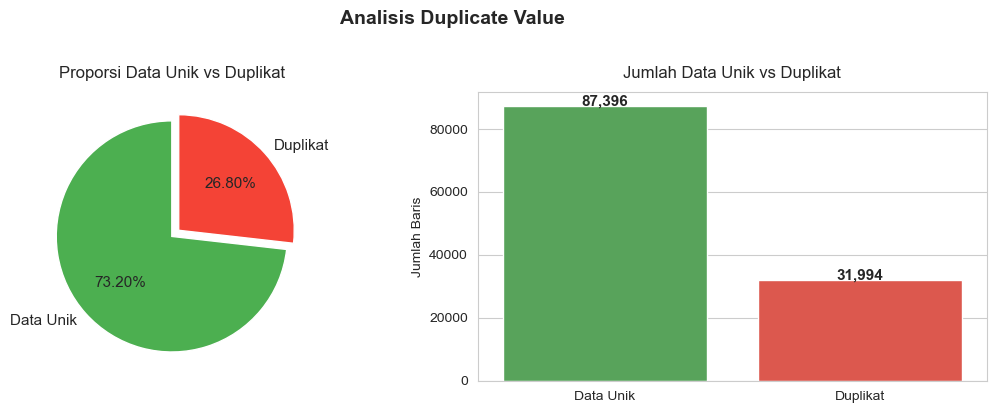

Total baris  : 119,390
Data unik    : 87,396
Duplikat     : 31,994


In [11]:
n_duplikat = df.duplicated().sum()
n_unik     = len(df) - n_duplikat

sns.set_style('whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Panel kiri: pie chart proporsi
labels  = ['Data Unik', 'Duplikat']
sizes   = [n_unik, n_duplikat]
colors  = ['#4CAF50', '#F44336']
explode = [0, 0.08]
axes[0].pie(sizes, labels=labels, autopct='%1.2f%%', colors=colors,
            explode=explode, startangle=90,
            textprops={'fontsize': 11})
axes[0].set_title('Proporsi Data Unik vs Duplikat', fontsize=12, pad=10)

# Panel kanan: bar chart perbandingan
bar_data = {'Kategori': ['Data Unik', 'Duplikat'], 'Jumlah': [n_unik, n_duplikat]}
bar_df = pd.DataFrame(bar_data)
bars = sns.barplot(data=bar_df, x='Kategori', y='Jumlah',
                   palette=['#4CAF50', '#F44336'], ax=axes[1])
for bar, val in zip(bars.patches, bar_df['Jumlah']):
    bars.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
              f'{val:,}', ha='center', fontsize=11, fontweight='bold')
axes[1].set_title('Jumlah Data Unik vs Duplikat', fontsize=12, pad=10)
axes[1].set_xlabel('')
axes[1].set_ylabel('Jumlah Baris')

plt.suptitle('Analisis Duplicate Value', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Total baris  : {len(df):,}")
print(f"Data unik    : {n_unik:,}")
print(f"Duplikat     : {n_duplikat:,}")

**Insight:** Dataset memiliki **31.994 baris duplikat (26.80%)** dari total 119.390 baris. Jumlah ini cukup signifikan sehingga perlu dilakukan penghapusan duplikat pada tahap preprocessing agar tidak mempengaruhi analisis.

## 11. Cek Apakah Ada Inconsistent Value

In [12]:
# Cek unique value hotel
print("Hotel types:", df['hotel'].unique())

# Cek unique value market_segment
print("\nMarket segments:", df['market_segment'].unique())

# Cek unique value customer_type
print("\nCustomer types:", df['customer_type'].unique())

# Cek unique value deposit_type
print("\nDeposit types:", df['deposit_type'].unique())

# Cek unique value meal
print("\nMeal types:", df['meal'].unique())

# Cek nilai adr negatif (tidak wajar)
print(f"\nJumlah ADR negatif: {(df['adr'] < 0).sum()}")
print(f"Nilai ADR maksimum: {df['adr'].max()}")

Hotel types: <ArrowStringArray>
['Resort Hotel', 'City Hotel']
Length: 2, dtype: str

Market segments: <ArrowStringArray>
[       'Direct',     'Corporate',     'Online TA', 'Offline TA/TO',
 'Complementary',        'Groups',     'Undefined',      'Aviation']
Length: 8, dtype: str

Customer types: <ArrowStringArray>
['Transient', 'Contract', 'Transient-Party', 'Group']
Length: 4, dtype: str

Deposit types: <ArrowStringArray>
['No Deposit', 'Refundable', 'Non Refund']
Length: 3, dtype: str

Meal types: <ArrowStringArray>
['BB', 'FB', 'HB', 'SC', 'Undefined']
Length: 5, dtype: str

Jumlah ADR negatif: 1
Nilai ADR maksimum: 5400.0


**Insight:** Terdapat nilai `Undefined` pada kolom `market_segment` dan `meal` yang perlu ditangani. Nilai `adr` (Average Daily Rate) memiliki maksimum 5400 yang sangat tinggi dan perlu dicek sebagai outlier.

## 12. Grafik Distribusi Pembatalan Pemesanan

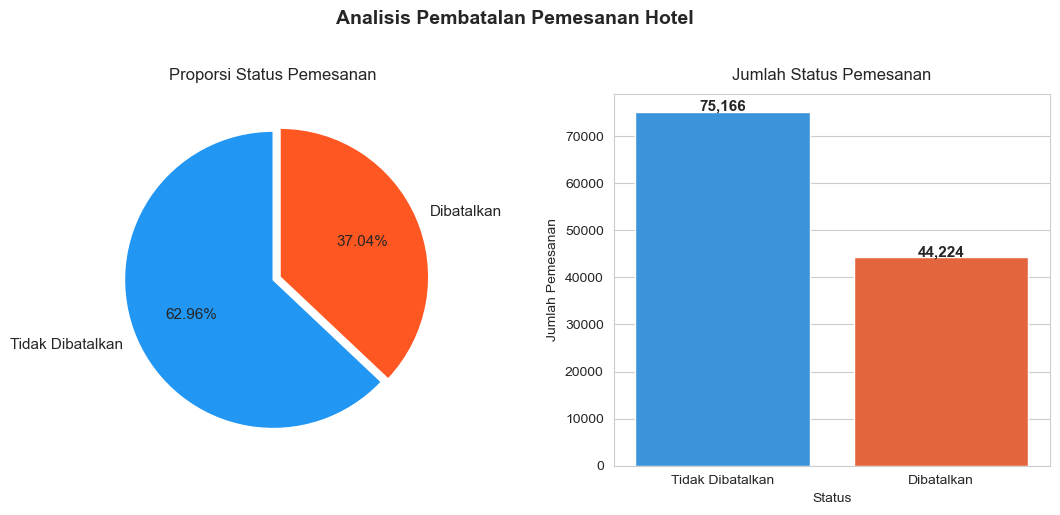

          Status  Jumlah
Tidak Dibatalkan   75166
      Dibatalkan   44224


In [13]:
sns.set_style('whitegrid')

cancel_counts = df['is_canceled'].value_counts().reset_index()
cancel_counts.columns = ['Status', 'Jumlah']
cancel_counts['Status'] = cancel_counts['Status'].map({0: 'Tidak Dibatalkan', 1: 'Dibatalkan'})

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# Pie chart
colors = ['#2196F3', '#FF5722']
axes[0].pie(cancel_counts['Jumlah'], labels=cancel_counts['Status'],
            autopct='%1.2f%%', colors=colors, startangle=90,
            explode=[0, 0.05], textprops={'fontsize': 11})
axes[0].set_title('Proporsi Status Pemesanan', fontsize=12, pad=10)

# Bar chart
bars = sns.barplot(data=cancel_counts, x='Status', y='Jumlah',
                   palette=colors, ax=axes[1])
for bar, val in zip(bars.patches, cancel_counts['Jumlah']):
    bars.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
              f'{val:,}', ha='center', fontsize=11, fontweight='bold')
axes[1].set_title('Jumlah Status Pemesanan', fontsize=12, pad=10)
axes[1].set_xlabel('Status')
axes[1].set_ylabel('Jumlah Pemesanan')

plt.suptitle('Analisis Pembatalan Pemesanan Hotel', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(cancel_counts.to_string(index=False))

**Insight:** Sebanyak **37.04%** pemesanan hotel mengalami pembatalan. Tingkat pembatalan yang cukup tinggi ini perlu dianalisis lebih lanjut untuk memahami faktor-faktor yang berkontribusi terhadap keputusan pembatalan.

## 13. Grafik Tren Pemesanan Hotel per Bulan

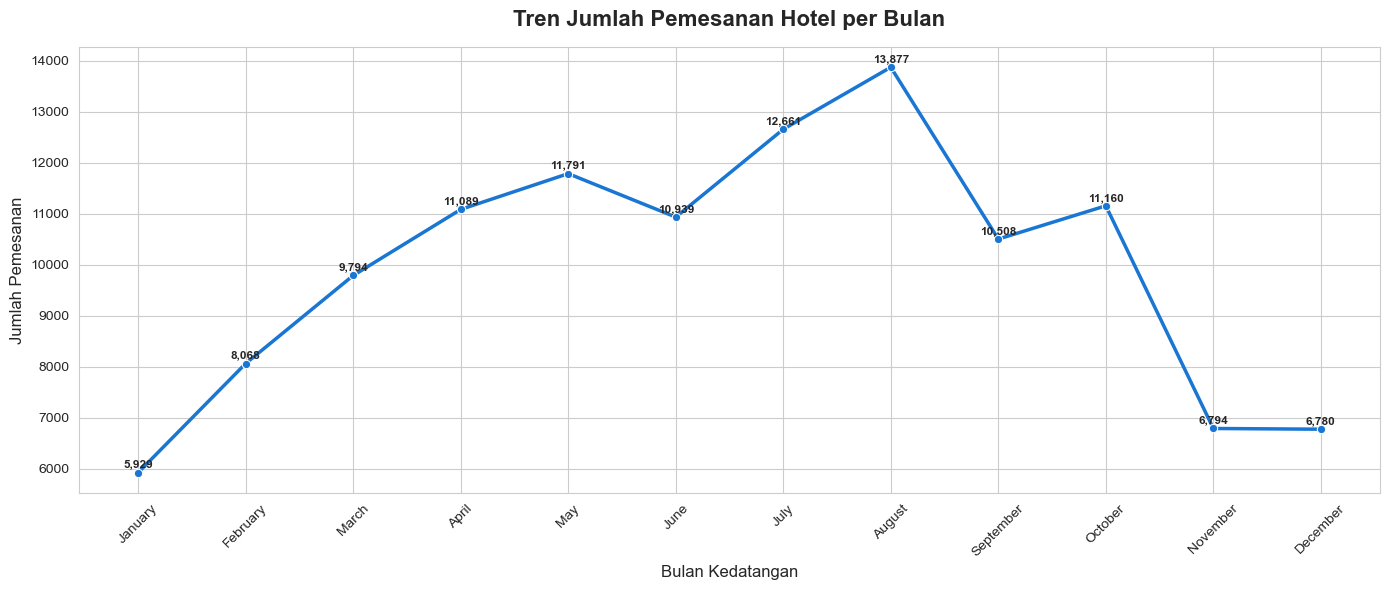

In [14]:
sns.set_style('whitegrid')

bulan_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

monthly = df.groupby('arrival_date_month').size().reindex(bulan_order).reset_index()
monthly.columns = ['Bulan', 'Jumlah Pemesanan']

plt.figure(figsize=(14, 6))
sns.lineplot(
    data=monthly,
    x='Bulan',
    y='Jumlah Pemesanan',
    marker='o',
    linewidth=2.5,
    color='#1976D2'
)

for i, row in monthly.iterrows():
    plt.text(i, row['Jumlah Pemesanan'] + 100, f"{row['Jumlah Pemesanan']:,}",
             ha='center', fontsize=8.5, fontweight='bold')

plt.title('Tren Jumlah Pemesanan Hotel per Bulan', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Bulan Kedatangan', fontsize=12)
plt.ylabel('Jumlah Pemesanan', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

**Insight:** Pemesanan hotel mencapai puncaknya pada bulan **Agustus** dan cenderung ramai di bulan-bulan musim panas (Juni–September), mengindikasikan adanya pola musiman yang kuat. Periode sepi terjadi di awal tahun (Januari–Februari).

## 14. Grafik Perbandingan Jenis Hotel

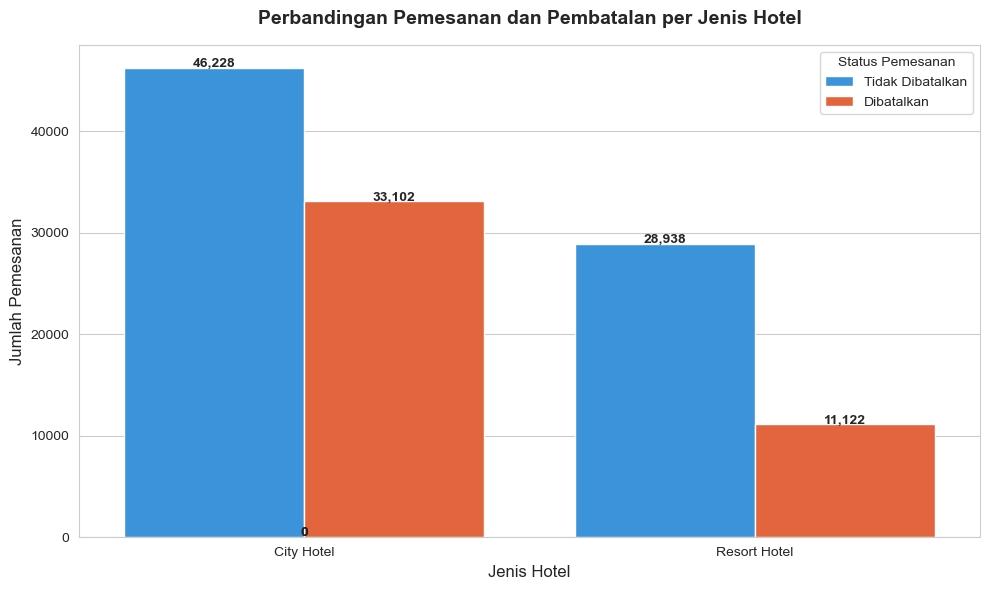

In [3]:
sns.set_style('whitegrid')

hotel_cancel = df.groupby(['hotel', 'is_canceled']).size().unstack(fill_value=0)
hotel_cancel.columns = ['Tidak Dibatalkan', 'Dibatalkan']
hotel_cancel = hotel_cancel.reset_index()

hotel_melt = hotel_cancel.melt(id_vars='hotel', var_name='Status', value_name='Jumlah')

plt.figure(figsize=(10, 6))
bars = sns.barplot(
    data=hotel_melt,
    x='hotel',
    y='Jumlah',
    hue='Status',
    palette=['#2196F3', '#FF5722']
)

for bar in bars.patches:
    bars.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
              f'{int(bar.get_height()):,}', ha='center', fontsize=10, fontweight='bold')

plt.title('Perbandingan Pemesanan dan Pembatalan per Jenis Hotel',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Jenis Hotel', fontsize=12)
plt.ylabel('Jumlah Pemesanan', fontsize=12)
plt.legend(title='Status Pemesanan')
plt.tight_layout()
plt.show()

**Insight:** **City Hotel** memiliki jumlah pemesanan jauh lebih tinggi dibanding Resort Hotel, namun juga memiliki tingkat pembatalan yang lebih tinggi secara absolut. Hal ini menunjukkan perbedaan karakteristik tamu antara kedua jenis hotel tersebut.

## 15. Grafik Distribusi Lead Time Pemesanan

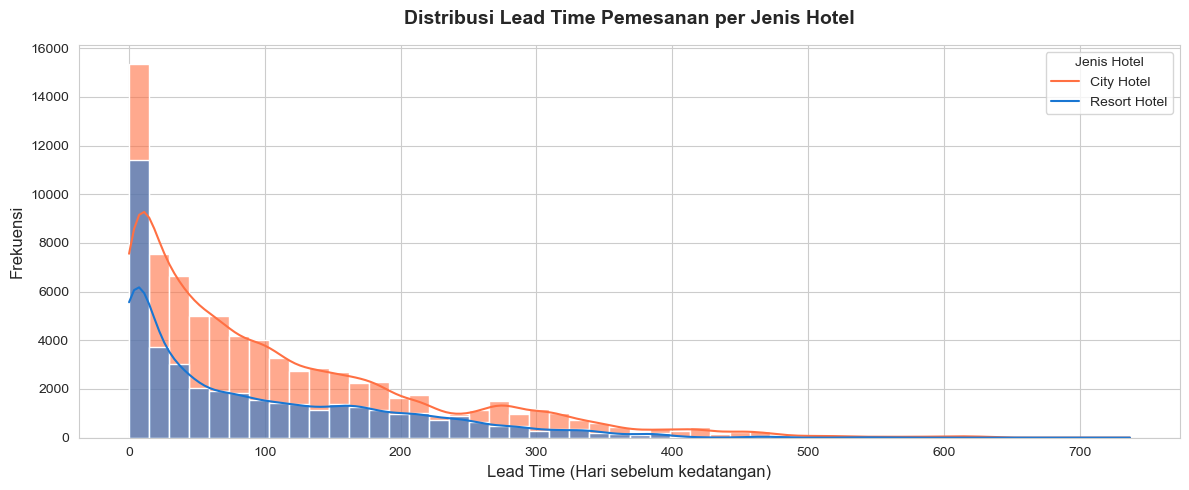

hotel    City Hotel  Resort Hotel
count  79330.000000  40060.000000
mean     109.735724     92.675686
std      110.948526     97.285315
min        0.000000      0.000000
25%       23.000000     10.000000
50%       74.000000     57.000000
75%      163.000000    155.000000
max      629.000000    737.000000


In [4]:
sns.set_style('whitegrid')

plt.figure(figsize=(12, 5))

sns.histplot(
    data=df,
    x='lead_time',
    hue='hotel',
    bins=50,
    kde=True,
    palette=['#1976D2', '#FF7043'],
    alpha=0.6
)

plt.title('Distribusi Lead Time Pemesanan per Jenis Hotel',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Lead Time (Hari sebelum kedatangan)', fontsize=12)
plt.ylabel('Frekuensi', fontsize=12)
plt.legend(title='Jenis Hotel', labels=['City Hotel', 'Resort Hotel'])
plt.tight_layout()
plt.show()

print(df.groupby('hotel')['lead_time'].describe().T)

**Insight:** Sebagian besar tamu melakukan pemesanan dalam waktu dekat (lead time rendah). City Hotel cenderung memiliki pemesanan mendadak lebih banyak dibanding Resort Hotel. Distribusi yang condong ke kanan menunjukkan adanya outlier dengan lead time sangat panjang hingga 737 hari.

## 16. Grafik Top 10 Negara Asal Tamu

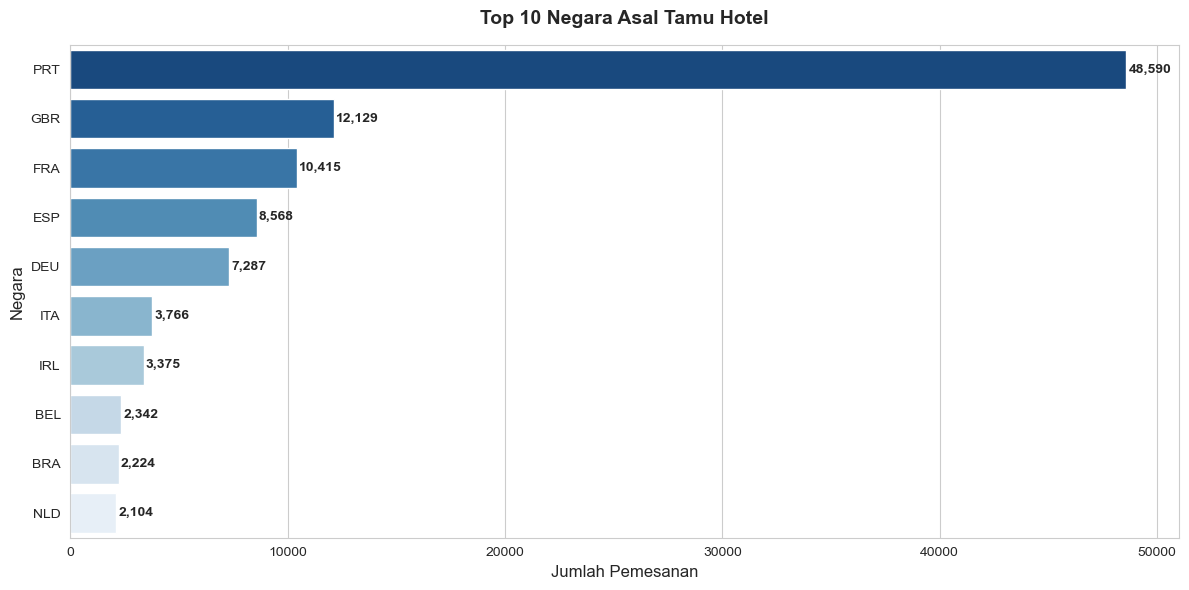

In [5]:
sns.set_style('whitegrid')

top_country = (
    df['country'].value_counts()
    .head(10)
    .reset_index()
)
top_country.columns = ['Negara', 'Jumlah']

plt.figure(figsize=(12, 6))
bars = sns.barplot(
    data=top_country,
    x='Jumlah',
    y='Negara',
    palette='Blues_r'
)

for bar, val in zip(bars.patches, top_country['Jumlah']):
    bars.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
              f'{val:,}', va='center', fontsize=10, fontweight='bold')

plt.title('Top 10 Negara Asal Tamu Hotel', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Jumlah Pemesanan', fontsize=12)
plt.ylabel('Negara', fontsize=12)
plt.tight_layout()
plt.show()

**Insight:** **Portugal (PRT)** mendominasi sebagai negara asal tamu terbanyak, diikuti oleh Inggris (GBR) dan Prancis (FRA). Hal ini wajar mengingat dataset berasal dari hotel-hotel di Portugal. Dominasi tamu Eropa menunjukkan bahwa hotel-hotel ini sangat bergantung pada wisatawan intra-Eropa.

## 17. Grafik Distribusi Average Daily Rate (ADR)

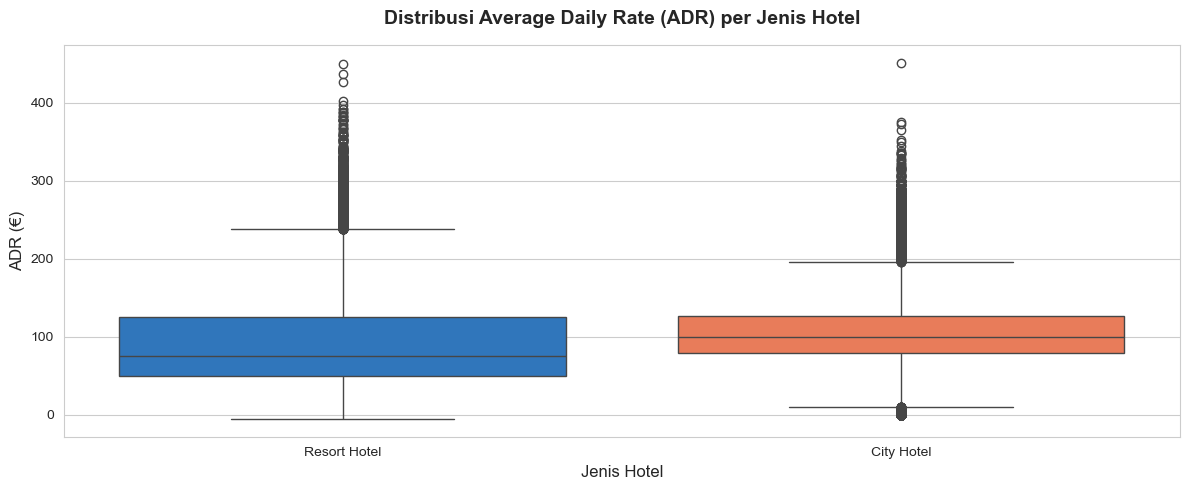

hotel    City Hotel  Resort Hotel
count  79330.000000  40060.000000
mean     105.304465     94.952930
std       43.602954     61.442418
min        0.000000     -6.380000
25%       79.200000     50.000000
50%       99.900000     75.000000
75%      126.000000    125.000000
max     5400.000000    508.000000


In [6]:
sns.set_style('whitegrid')

# Filter outlier ekstrem untuk visualisasi yang lebih jelas
df_adr = df[df['adr'] < 500]

plt.figure(figsize=(12, 5))
sns.boxplot(
    data=df_adr,
    x='hotel',
    y='adr',
    palette=['#1976D2', '#FF7043']
)

plt.title('Distribusi Average Daily Rate (ADR) per Jenis Hotel',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Jenis Hotel', fontsize=12)
plt.ylabel('ADR (€)', fontsize=12)
plt.tight_layout()
plt.show()

print(df.groupby('hotel')['adr'].describe().T)

**Insight:** **Resort Hotel** memiliki rata-rata ADR yang lebih tinggi dibanding City Hotel, menunjukkan bahwa tarif menginap di resort cenderung lebih mahal. Terdapat banyak outlier pada kedua jenis hotel, terutama pada nilai ADR yang sangat tinggi, yang perlu ditangani saat preprocessing.

## 18. Grafik Market Segment vs Tingkat Pembatalan

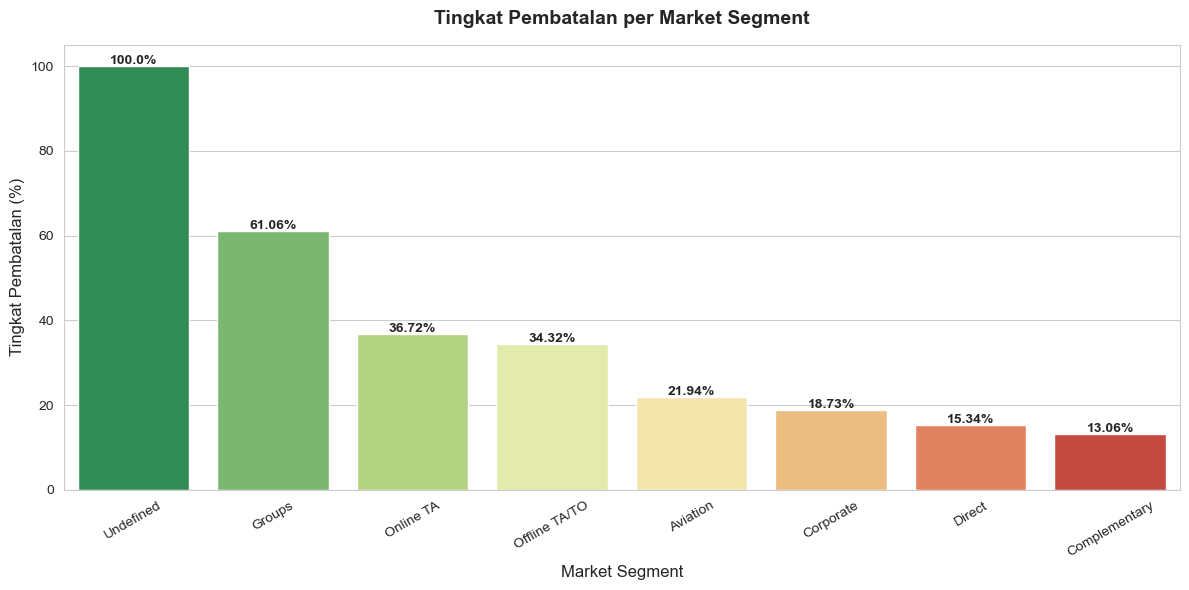

In [7]:
sns.set_style('whitegrid')

segment_cancel = (
    df.groupby('market_segment')['is_canceled']
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
    .reset_index()
)
segment_cancel.columns = ['Market Segment', 'Tingkat Pembatalan (%)']

plt.figure(figsize=(12, 6))
bars = sns.barplot(
    data=segment_cancel,
    x='Market Segment',
    y='Tingkat Pembatalan (%)',
    palette='RdYlGn_r'
)

for bar, val in zip(bars.patches, segment_cancel['Tingkat Pembatalan (%)']):
    bars.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
              f'{val}%', ha='center', fontsize=10, fontweight='bold')

plt.title('Tingkat Pembatalan per Market Segment', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Market Segment', fontsize=12)
plt.ylabel('Tingkat Pembatalan (%)', fontsize=12)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Insight:** Segmen **Groups** dan **Online TA (Travel Agent)** memiliki tingkat pembatalan tertinggi. Hal ini menunjukkan bahwa pemesanan melalui agen perjalanan online dan grup lebih rentan dibatalkan dibanding pemesanan langsung (Direct) atau korporat (Corporate).

## 19. Heatmap Korelasi Fitur Numerik

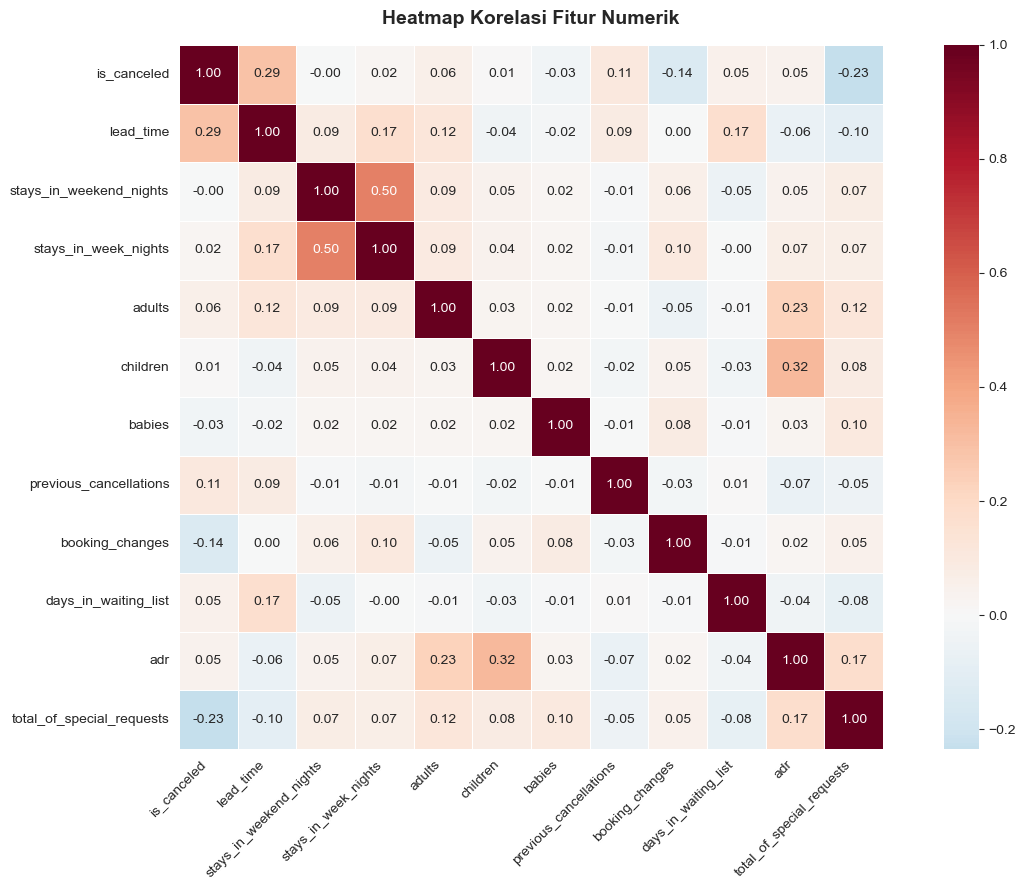

In [8]:
sns.set_style('white')

numeric_cols = ['is_canceled', 'lead_time', 'stays_in_weekend_nights',
                'stays_in_week_nights', 'adults', 'children', 'babies',
                'previous_cancellations', 'booking_changes',
                'days_in_waiting_list', 'adr', 'total_of_special_requests']

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(13, 9))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    linewidths=0.5,
    square=True
)

plt.title('Heatmap Korelasi Fitur Numerik', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Insight:** Kolom `is_canceled` berkorelasi positif dengan `lead_time` dan `previous_cancellations`, artinya pemesanan dengan waktu tunggu lebih lama dan riwayat pembatalan sebelumnya cenderung lebih sering dibatalkan. `total_of_special_requests` berkorelasi negatif dengan `is_canceled`, menunjukkan tamu yang memiliki banyak permintaan khusus lebih jarang membatalkan pemesanannya.

## 20. Rangkuman EDA

Eksplorasi data (*Exploratory Data Analysis*) ini dilakukan terhadap dataset **Hotel Bookings**,
yang berisi data pemesanan hotel dari dua jenis hotel — City Hotel dan Resort Hotel — beserta
informasi tamu, lead time, segmen pasar, negara asal, tarif harian, dan status pembatalan.

Berikut ringkasan tahapan EDA yang telah dilakukan:

| No | Tahap | Keterangan |
|----|-------|------------|
| 1 | Import Library | Menggunakan `pandas`, `numpy`, `matplotlib`, dan `seaborn` |
| 2 | Load Dataset | Dataset dimuat dari file `hotel_bookings.csv` |
| 3 | Struktur Dataset | Mengecek jumlah baris, kolom, dan nama kolom |
| 4 | Preview Data | Menampilkan 5 baris teratas dengan `df.head()` |
| 5 | Ringkasan Info | Melihat tipe data dan info umum dengan `df.info()` |
| 6 | Statistik Deskriptif | Analisis distribusi data numerik dengan `df.describe()` |
| 7 | Missing Value | Mengecek nilai yang hilang dengan `df.isnull().sum()` |
| 8 | Visualisasi Missing Value | Menampilkan grafik jumlah dan persentase missing value |
| 9 | Duplicate Value | Mengecek data duplikat dengan `df.duplicated().sum()` |
| 10 | Visualisasi Duplicate Value | Menampilkan pie chart dan bar chart duplikat |
| 11 | Cek Inconsistent Value | Mengecek data yang tidak konsisten dengan `unique` dan nilai ADR negatif |
| 12 | Distribusi Pembatalan | Pie chart dan bar chart proporsi pemesanan dibatalkan vs tidak |
| 13 | Tren Bulanan | Line chart jumlah pemesanan per bulan kedatangan |
| 14 | Perbandingan Jenis Hotel | Bar chart pemesanan dan pembatalan per jenis hotel |
| 15 | Distribusi Lead Time | Histogram distribusi lead time per jenis hotel |
| 16 | Top 10 Negara Asal | Bar chart horizontal negara asal tamu terbanyak |
| 17 | Distribusi ADR | Boxplot Average Daily Rate per jenis hotel |
| 18 | Market Segment vs Pembatalan | Bar chart tingkat pembatalan per segmen pasar |
| 19 | Heatmap Korelasi | Heatmap korelasi antar fitur numerik |

## 21. Kesimpulan
Berdasarkan hasil EDA yang telah dilakukan, diperoleh beberapa temuan penting:

1. **Missing Value** — Kolom `company` memiliki missing value sangat tinggi sebesar **94.31%** (112.593 baris) sehingga perlu dipertimbangkan untuk dihapus. Kolom `agent` memiliki **13.69%** missing value, sedangkan `country` (0.41%) dan `children` (0.003%) tergolong kecil dan dapat ditangani dengan imputasi.

2. **Duplicate Value** — Dataset mengandung **31.994 baris duplikat (26.80%)** dari total 119.390 baris. Jumlah ini cukup signifikan dan harus dihapus pada tahap preprocessing untuk menjaga integritas analisis.

3. **Tingkat Pembatalan Tinggi** — Sebanyak **37.04%** pemesanan hotel dibatalkan. Angka ini cukup tinggi dan menunjukkan perlunya strategi pengelolaan reservasi yang lebih baik, seperti kebijakan deposit atau overbooking yang terkalkulasi.

4. **Pola Musiman Pemesanan** — Pemesanan hotel mencapai puncaknya pada bulan **Agustus** dan umumnya tinggi selama musim panas (Juni–September). Periode sepi terjadi di awal tahun (Januari–Februari), mengindikasikan pola musiman yang kuat dan bisa dimanfaatkan untuk strategi harga dinamis.

5. **City Hotel Lebih Dominan** — City Hotel memiliki jumlah pemesanan jauh lebih tinggi dibanding Resort Hotel, namun juga mengalami pembatalan lebih banyak secara absolut. Ini mencerminkan perbedaan karakteristik tamu — tamu City Hotel cenderung lebih fleksibel dalam mengubah rencana perjalanan.

6. **Lead Time dan Pembatalan** — Sebagian besar tamu memesan dalam waktu dekat (lead time rendah). Semakin panjang lead time, semakin tinggi kemungkinan pembatalan — terlihat dari korelasi positif antara `lead_time` dan `is_canceled` pada heatmap.

7. **Dominasi Tamu Eropa** — Portugal (PRT) menjadi negara asal tamu terbanyak, diikuti Inggris (GBR) dan Prancis (FRA). Pasar hotel ini sangat bergantung pada wisatawan intra-Eropa, sehingga kondisi ekonomi dan kebijakan perjalanan di Eropa berdampak langsung pada tingkat hunian.

8. **ADR Resort Hotel Lebih Tinggi** — Resort Hotel memiliki rata-rata *Average Daily Rate* (ADR) yang lebih tinggi dibanding City Hotel, konsisten dengan ekspektasi bahwa resort menawarkan pengalaman premium. Kedua jenis hotel memiliki outlier ADR yang ekstrem (hingga €5.400) yang perlu ditangani saat preprocessing.

9. **Segmen Online TA Rentan Dibatalkan** — Segmen **Groups** dan **Online TA** memiliki tingkat pembatalan tertinggi. Pemesanan langsung (Direct) dan korporat (Corporate) cenderung lebih stabil. Ini mengimplikasikan bahwa pemesanan via agen perjalanan online lebih bersifat spekulatif.

10. **Faktor Pembatalan** — Dari heatmap korelasi, `previous_cancellations` dan `lead_time` berkorelasi positif dengan `is_canceled`, sedangkan `total_of_special_requests` berkorelasi negatif. Artinya, tamu yang pernah membatalkan sebelumnya lebih cenderung membatalkan lagi, sementara tamu dengan banyak permintaan khusus justru lebih berkomitmen pada pemesanannya.

> **Catatan:** Dataset ini mengandung duplikat yang cukup banyak (26.80%) dan kolom `company` dengan missing value sangat tinggi (94.31%) yang wajib ditangani sebelum pemodelan atau analisis lanjutan dilakukan.